# 1. Random Forest

In [1]:
import pandas as pd
import numpy as np

X_train = pd.read_parquet("/kaggle/input/datasets/nadianoumee/ids2017-preprocessing/X_train.parquet")
X_test = pd.read_parquet("/kaggle/input/datasets/nadianoumee/ids2017-preprocessing/X_test.parquet")

y_train = pd.read_parquet("/kaggle/input/datasets/nadianoumee/ids2017-preprocessing/y_train.parquet")["Label"]
y_test = pd.read_parquet("/kaggle/input/datasets/nadianoumee/ids2017-preprocessing/y_test.parquet")["Label"]

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

label_mapping = pd.read_csv("/kaggle/input/datasets/nadianoumee/ids2017-preprocessing/label_mapping.csv")
class_names = label_mapping["class_name"].values

(1785379, 77)
(446345, 77)
(1785379,)
(446345,)


In [2]:
from sklearn.ensemble import RandomForestClassifier

rf_before = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

rf_before.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced_subsample', n_jobs=-1,
                       random_state=42)

In [3]:
import joblib

joblib.dump(
    rf_before,
    "/kaggle/working/rf_model.pkl"
)

print("Random Forest model saved.")

Random Forest model saved.


In [4]:
y_pred_rf_before = rf_before.predict(X_test)
y_prob_rf_before = rf_before.predict_proba(X_test)

In [5]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    classification_report
)
from sklearn.preprocessing import label_binarize

# Binarize labels for multiclass AUC
classes = np.arange(len(class_names))

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

# Weighted metrics
accuracy = accuracy_score(y_test, y_pred_rf_before)

precision_weighted = precision_score(
    y_test, y_pred_rf_before,
    average="weighted",
    zero_division=0
)

recall_weighted = recall_score(
    y_test, y_pred_rf_before,
    average="weighted",
    zero_division=0
)

f1_weighted = f1_score(
    y_test, y_pred_rf_before,
    average="weighted",
    zero_division=0
)

# Macro metrics
precision_macro = precision_score(
    y_test, y_pred_rf_before,
    average="macro",
    zero_division=0
)

recall_macro = recall_score(
    y_test, y_pred_rf_before,
    average="macro",
    zero_division=0
)

f1_macro = f1_score(
    y_test, y_pred_rf_before,
    average="macro",
    zero_division=0
)

# MCC
mcc = matthews_corrcoef(y_test, y_pred_rf_before)

# Multiclass AUC
auc = roc_auc_score(
    y_test_bin,
    y_prob_rf_before,
    multi_class="ovr",
    average="weighted"
)

print(f"Accuracy          : {accuracy:.4f}")
print(f"Weighted Precision: {precision_weighted:.4f}")
print(f"Weighted Recall   : {recall_weighted:.4f}")
print(f"Weighted F1       : {f1_weighted:.4f}")
print(f"Macro Precision   : {precision_macro:.4f}")
print(f"Macro Recall      : {recall_macro:.4f}")
print(f"Macro F1          : {f1_macro:.4f}")
print(f"MCC               : {mcc:.4f}")
print(f"AUC               : {auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf_before,
    target_names=class_names,
    zero_division=0
))

Accuracy          : 0.9984
Weighted Precision: 0.9984
Weighted Recall   : 0.9984
Weighted F1       : 0.9984
Macro Precision   : 0.9262
Macro Recall      : 0.8377
Macro F1          : 0.8639
MCC               : 0.9941
AUC               : 0.9999

Classification Report:
                            precision    recall  f1-score   support

                    Benign       1.00      1.00      1.00    379047
                       Bot       0.83      0.63      0.72       288
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       1.00      0.99      1.00      2057
                  DoS Hulk       1.00      1.00      1.00     34569
          DoS Slowhttptest       0.96      0.99      0.97      1046
             DoS slowloris       1.00      1.00      1.00      1077
               FTP-Patator       1.00      0.99      1.00      1186
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      0.71     

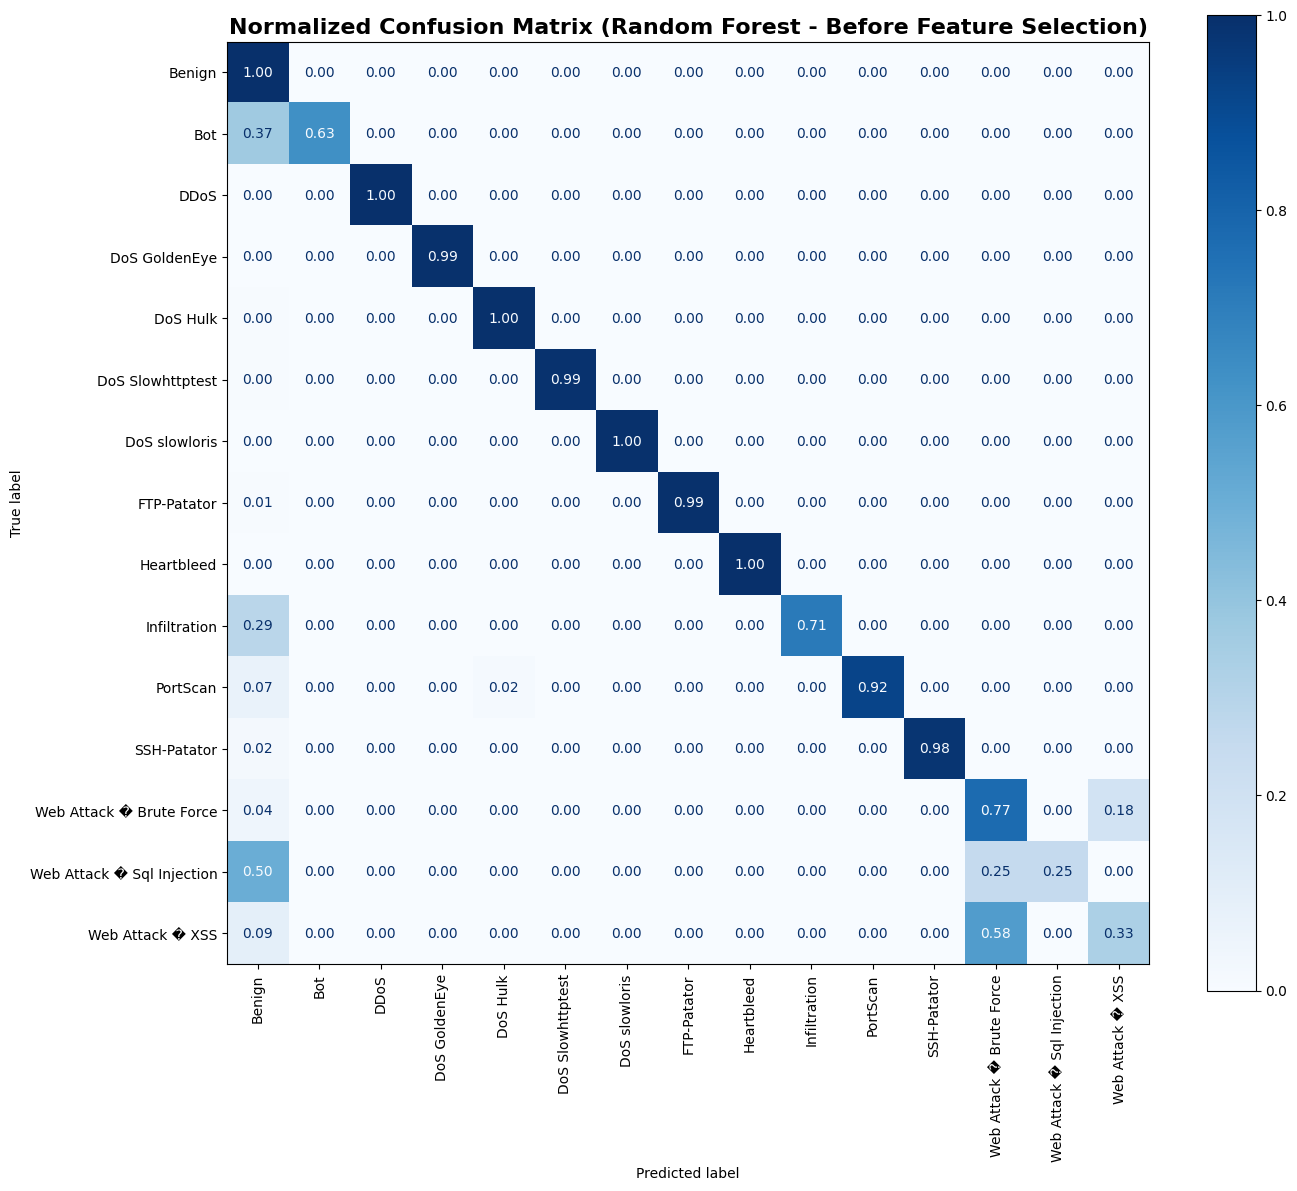

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(14, 12))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf_before,
    labels=classes,
    display_labels=class_names,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=90,
    ax=ax
)

plt.title(
    "Normalized Confusion Matrix "
    "(Random Forest - Before Feature Selection)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/rf_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [7]:
rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [accuracy],
    "Weighted Precision": [precision_weighted],
    "Weighted Recall": [recall_weighted],
    "Weighted F1": [f1_weighted],
    "Macro Precision": [precision_macro],
    "Macro Recall": [recall_macro],
    "Macro F1": [f1_macro],
    "MCC": [mcc],
    "AUC": [auc]
})

rf_results.to_csv("/kaggle/working/rf_results.csv", index=False)

print(rf_results)

           Model  Accuracy  Weighted Precision  Weighted Recall  Weighted F1  \
0  Random Forest  0.998412            0.998354         0.998412     0.998368   

   Macro Precision  Macro Recall  Macro F1       MCC       AUC  
0         0.926153      0.837711  0.863917  0.994101  0.999877  


In [8]:
rf_predictions = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_rf_before
})

rf_predictions.to_csv(
    "/kaggle/working/rf_predictions.csv",
    index=False
)